In [1]:
#Import necessary libraries
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from scipy.stats import pointbiserialr
import matplotlib.pyplot as plt

In [2]:
#Download IVV ETF data from Yahoo Finance
ivv = yf.download('IVV', start='2010-01-01', end='2020-01-01')

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [3]:
#Use 'Adj Close' if available, otherwise fallback to 'Close'
price_col = 'Adj Close' if 'Adj Close' in ivv.columns else 'Close'


In [4]:
#Calculate daily returns and create lagged return feature
ivv['Return'] = ivv[price_col].pct_change()
ivv['Lag1'] = ivv['Return'].shift(1)
ivv.dropna(inplace=True)

In [5]:
#Create features (X) and binary labels (y)
X = ivv[['Lag1']].values
y = np.where(ivv['Return'] > 0, 1, 0)

In [6]:
#5-Fold Cross-Validation using Point-Biserial Correlation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
correlations = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X), 1):
    X_test = X[test_idx]
    y_test = y[test_idx]
    
    # Calculate point-biserial correlation
    corr, _ = pointbiserialr(y_test.flatten(), X_test.flatten())
    correlations.append(corr)
    print(f"Fold {fold} Correlation: {corr:.4f}")

Fold 1 Correlation: -0.0081
Fold 2 Correlation: -0.0233
Fold 3 Correlation: 0.0077
Fold 4 Correlation: -0.0827
Fold 5 Correlation: -0.0323


In [7]:
#Display average correlation across folds
average_corr = np.mean(correlations)
print(f"\nAverage Cross-Validated Correlation: {average_corr:.4f}")


Average Cross-Validated Correlation: -0.0277


In [8]:
#Create and display results table
results_df = pd.DataFrame({
    'Fold': list(range(1, 6)),
    'Correlation': correlations
})
results_df.loc['Average'] = ['Average', average_corr]
print("\nCross-Validation Results Table:\n", results_df)


Cross-Validation Results Table:
             Fold  Correlation
0              1    -0.008134
1              2    -0.023275
2              3     0.007699
3              4    -0.082747
4              5    -0.032265
Average  Average    -0.027744


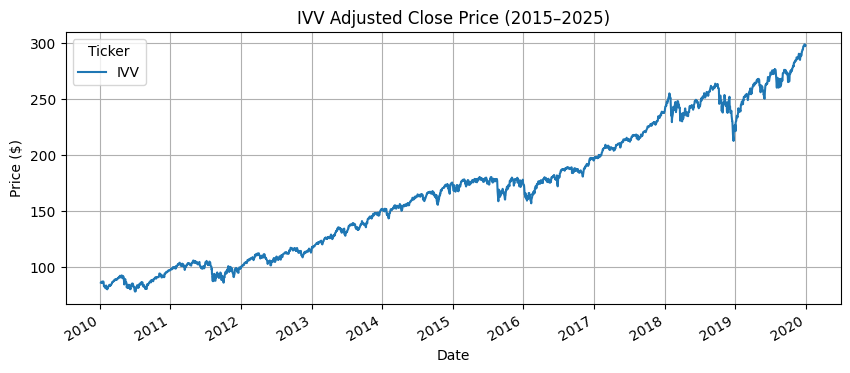

In [9]:
#Plot IVV Adjusted Close Price over time
ivv[price_col].plot(title='IVV Adjusted Close Price (2015–2025)', figsize=(10, 4))
plt.ylabel('Price ($)')
plt.xlabel('Date')
plt.grid(True)
plt.show()


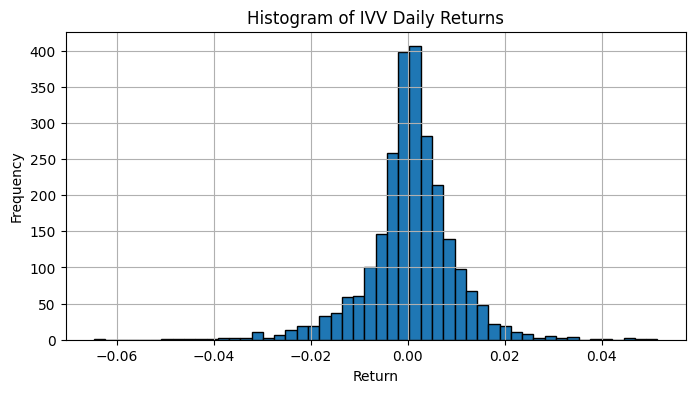

In [10]:
#Histogram of Daily Returns
ivv['Return'].hist(bins=50, edgecolor='black', figsize=(8, 4))
plt.title('Histogram of IVV Daily Returns')
plt.xlabel('Return')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

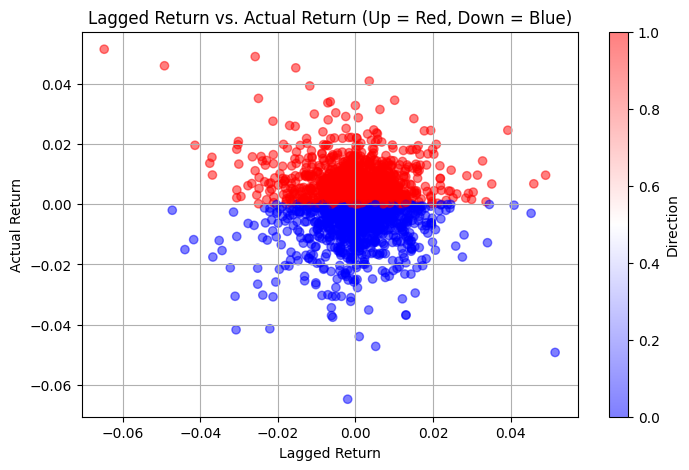

In [11]:
#Scatter Plot of Lagged vs. Actual Return, Colored by Class
ivv['Direction'] = y  # Add binary direction column (1 = up, 0 = down)

plt.figure(figsize=(8, 5))
scatter = plt.scatter(ivv['Lag1'], ivv['Return'], c=ivv['Direction'], cmap='bwr', alpha=0.5)
plt.title('Lagged Return vs. Actual Return (Up = Red, Down = Blue)')
plt.xlabel('Lagged Return')
plt.ylabel('Actual Return')
plt.grid(True)
plt.colorbar(scatter, label='Direction')
plt.show()